## Eval ppl on holdout data for different models at the AA level

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()

In [5]:
samples_dir = "results/inf_eval"
peint_df = pd.read_csv(f"{samples_dir}/peint_model_d4.csv")
peint_650m_df = pd.read_csv(f"{samples_dir}/peint_650m_model_d4.csv")
codon_df = pd.read_csv(f"{samples_dir}/codon_model_aa_vocab_dx.csv")
ctmc_df = pd.read_csv(f"{samples_dir}/ctmc_model_d4.csv")
# dasm_opt_bl_df = pd.read_csv(f"{samples_dir}/dasm_opt_bls_d4.csv")
dasm_og_bl_df = pd.read_csv(f"{samples_dir}/dasm_orig_bls_dx.csv")

/tmp/ipykernel_998461/588796381.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='model', y='perplexity', order=order, palette=palette, ax=ax, showmeans=False)


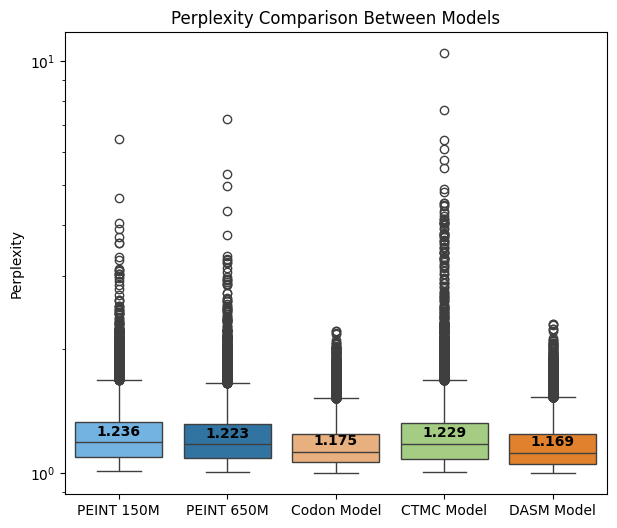

In [10]:
# whisker plot perplexity column. color by method and annotate mean above each box
combined = pd.concat([
    peint_df.assign(model='PEINT 150M'),
    peint_650m_df.assign(model='PEINT 650M'),
    ctmc_df.assign(model='CTMC Model'),
    codon_df.assign(model='Codon Model'),
    dasm_og_bl_df.assign(model='DASM Model'),
], ignore_index=True)

order = ['PEINT 150M', 'PEINT 650M', 'Codon Model', 'CTMC Model', 'DASM Model']
palette = {'PEINT 150M': "#60b6f4", 'PEINT 650M': "#1f77b4", 'Codon Model': "#fbaf6d", 'CTMC Model': "#a3d977", 'DASM Model': "#ff7f0e"}

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=combined, x='model', y='perplexity', order=order, palette=palette, ax=ax, showmeans=False)
ax.set_title('Perplexity Comparison Between Models')
ax.set_xlabel('')
ax.set_ylabel('Perplexity')
ax.set_yscale('log')

# compute means and annotate
means = combined.groupby('model')['perplexity'].mean()
for i, m in enumerate(order):
    mean_val = means.loc[m]
    y = mean_val * 0.98
    ax.text(i, y, f"{mean_val:.3f}", ha='center', va='bottom', fontweight='bold')

plt.show()

/tmp/ipykernel_3162302/758342829.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=runtime_df, x='model', y='runtime', order=order, palette=palette, ax=ax)


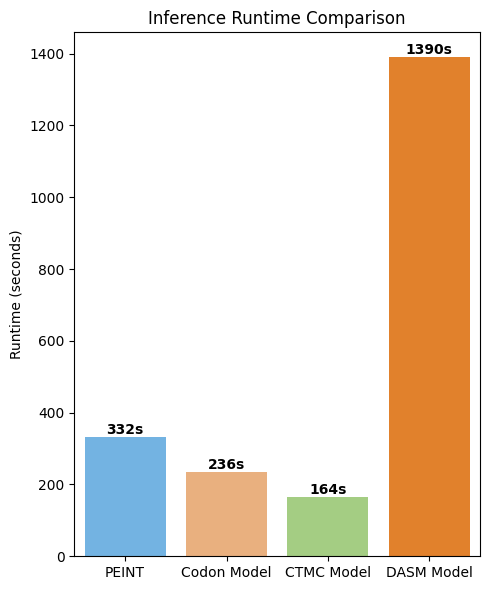

In [48]:
runtime_in_seconds = {
    "PEINT": 5*60+32,
    "Codon Model": 180+56,
    "CTMC Model": 120+44,
    "DASM Model": 1390
}
order = ['PEINT', 'Codon Model', 'CTMC Model', 'DASM Model']
palette = {'PEINT': "#60b6f4", 'Codon Model': "#fbaf6d", 'CTMC Model': "#a3d977", 'DASM Model': "#ff7f0e"}

# Create runtime comparison plot
runtime_df = pd.DataFrame(list(runtime_in_seconds.items()), columns=['model', 'runtime'])

fig, ax = plt.subplots(figsize=(5, 6))
sns.barplot(data=runtime_df, x='model', y='runtime', order=order, palette=palette, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Runtime (seconds)')
ax.set_title('Inference Runtime Comparison')

# Annotate bars with values
for i, m in enumerate(order):
    runtime_val = runtime_in_seconds[m]
    ax.text(i, runtime_val, f"{runtime_val}s", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## Eval perplexity broken down by CDR and FR regions

In [3]:
import os
import numpy as np
from tqdm import tqdm
from typing import List

from Bio.Seq import Seq
from evo.antibody import compute_region_masks_batch
from evo.dataset import ComplexCherriesDataset
from evo.tensor import collate_list_of_dicts

/accounts/projects/yss/stephen.lu/peint-workspace/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [6]:
# populate this with the final data points
import pickle
final_data = []

with open("../results/inf_eval/final_data.pkl", "rb") as f:
    final_data = pickle.load(f)

unique_methods = set([item["model"] for item in final_data])
print(unique_methods)

num_cpus = os.cpu_count()
print(f"Using {num_cpus} CPUs for mask computation.")

{'PEINT v2', 'Codon', 'CTMC', 'PEINT'}
Using 16 CPUs for mask computation.


In [7]:
def extract_sequences_from_dataset(dataset: ComplexCherriesDataset, translate: bool = False):
    all_seqs = [item[1] for item in dataset]    # List[[str, str]]
    hv_seqs, lt_seqs = zip(*all_seqs)
    if translate:
        hv_seqs = [str(Seq(hv).translate()) for hv in tqdm(hv_seqs)]
        lt_seqs = [str(Seq(lt).translate()) for lt in tqdm(lt_seqs)]
    return hv_seqs, lt_seqs


def compute_masks(hv_seqs: List[str], lt_seqs: List[str], num_workers: int = 8):
    hv_masks = compute_region_masks_batch(hv_seqs, num_workers=num_workers, scheme="imgt", show_progress=True, raise_on_error=True)  # List[Dict[str, np.ndarray]]
    lt_masks = compute_region_masks_batch(lt_seqs, num_workers=num_workers, scheme="imgt", show_progress=True, raise_on_error=True)  # List[Dict[str, np.ndarray]]
    hv_masks = collate_list_of_dicts(hv_masks, hv_masks[0].keys(), constant_value=False)    # Dict[str, np.ndarray]
    lt_masks = collate_list_of_dicts(lt_masks, lt_masks[0].keys(), constant_value=False)    # Dict[str, np.ndarray]
    return hv_masks, lt_masks


def add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method: str):
    assert hv_masks["FR1"].shape == hv_nlls.shape
    assert lt_masks["FR1"].shape == lt_nlls.shape
    
    # check if method is already in the final_data
    unique_methods = set([item["model"] for item in final_data])
    if method in unique_methods:
        print(f"Method {method} already in final_data, skipping...")
        return

    # compute lls and ppls for each region
    for region in hv_masks.keys():
        hv_reg_mean_nll = (hv_nlls * hv_masks[region]).sum(-1) / hv_masks[region].sum(-1)
        lt_reg_mean_nll = (lt_nlls * lt_masks[region]).sum(-1) / lt_masks[region].sum(-1)
        hv_tot_mean_nll = hv_nlls.sum(-1) / hv_szs
        lt_tot_mean_nll = lt_nlls.sum(-1) / lt_szs
        
        final_data.extend([
            {"chain": "heavy", "region": region, "model": method, "ppl": ppl}
            for ppl in np.exp(hv_reg_mean_nll).tolist()
        ])
        final_data.extend([
            {"chain": "light", "region": region, "model": method, "ppl": ppl}
            for ppl in np.exp(lt_reg_mean_nll).tolist()
        ])
        final_data.extend([
            {"chain": "heavy", "region": "total", "model": method, "ppl": ppl}
            for ppl in np.exp(hv_tot_mean_nll).tolist()
        ])
        final_data.extend([
            {"chain": "light", "region": "total", "model": method, "ppl": ppl}
            for ppl in np.exp(lt_tot_mean_nll).tolist()
        ])


In [9]:
# calculate regions for ctmc inference dataset
ctmc_nlls = np.load("../results/inf_eval/ctmc_nlls_d4.npz")  # (num_samples, seq_len)
hv_nlls, lt_nlls, hv_szs, lt_szs = ctmc_nlls["hv_nlls"], ctmc_nlls["lt_nlls"], ctmc_nlls["hv_szs"], ctmc_nlls["lt_szs"]

# check if method is already in the final_data
if "CTMC" in unique_methods:
    print(f"Method CTMC already in final_data, skipping...")
else:
    dataset = ComplexCherriesDataset(data_file="../data/wyatt/subs/edges_joint/aa/d4.txt", min_t=0.)
    hv_seqs, lt_seqs = extract_sequences_from_dataset(dataset, translate=False)
    hv_masks, lt_masks = compute_masks(hv_seqs, lt_seqs, num_workers=num_cpus)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method="CTMC")

Computing masks: 100%|██████████| 60403/60403 [03:43<00:00, 269.74it/s]
/tmp/ipykernel_1852142/1305127825.py:30: RuntimeWarning: invalid value encountered in divide
  hv_reg_mean_nll = (hv_nlls * hv_masks[region]).sum(-1) / hv_masks[region].sum(-1)


In [10]:
# calculate regions for peint inference dataset
peint_nlls = np.load("../results/inf_eval/peint_nlls_d4.npz")
hv_nlls, lt_nlls, hv_szs, lt_szs = peint_nlls['hv_nlls'], peint_nlls['lt_nlls'], peint_nlls['hv_szs'], peint_nlls['lt_szs']

if "PEINT" in unique_methods:
    print(f"Method PEINT already in final_data, skipping...")
else:
    dataset = ComplexCherriesDataset(data_file="../data/wyatt/subs/edges_joint/aa/d4.txt", min_t=0.)
    hv_seqs, lt_seqs = extract_sequences_from_dataset(dataset, translate=False)
    hv_masks, lt_masks = compute_masks(hv_seqs, lt_seqs, num_workers=15)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method="PEINT")

Method PEINT already in final_data, skipping...


In [18]:
# calculate regions for peint inference dataset
peint_nlls = np.load("results/inf_eval/peint_650m_nlls_d4.npz")
hv_nlls, lt_nlls, hv_szs, lt_szs = peint_nlls['hv_nlls'], peint_nlls['lt_nlls'], peint_nlls['hv_szs'], peint_nlls['lt_szs']

if "PEINT 650M" in unique_methods:
    print(f"Method PEINT 650M already in final_data, skipping...")
else:
    dataset = ComplexCherriesDataset(data_file="data/wyatt/subs/edges_joint/aa/d4.txt", min_t=0.)
    hv_seqs, lt_seqs = extract_sequences_from_dataset(dataset, translate=False)
    hv_masks, lt_masks = compute_masks(hv_seqs, lt_seqs, num_workers=15)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method="PEINT 650M")

Computing masks:   0%|                                                                               | 0/60403 [00:00<?, ?it/s]

Computing masks: 100%|██████████████████████████████████████████████████████████████████| 60403/60403 [03:26<00:00, 292.74it/s]
/tmp/ipykernel_998461/1305127825.py:30: RuntimeWarning: invalid value encountered in divide
  hv_reg_mean_nll = (hv_nlls * hv_masks[region]).sum(-1) / hv_masks[region].sum(-1)


In [11]:
# calculate regions for codon inference dataset
codon_nlls = np.load("../results/inf_eval/codon_nlls_d4.npz")
# codon_nlls = np.load("../results/inf_eval/codon_nlls_bw_d4.npz")
hv_nlls, lt_nlls, hv_szs, lt_szs = codon_nlls['hv_nlls'], codon_nlls['lt_nlls'], codon_nlls['hv_szs'], codon_nlls['lt_szs']

if "Codon" in unique_methods:
    print(f"Method Codon already in final_data, skipping...")
else:
    dataset = ComplexCherriesDataset(data_file="../data/wyatt/subs/edges_joint/nt/d4.txt", min_t=0.)
    hv_seqs, lt_seqs = extract_sequences_from_dataset(dataset, translate=True)
    hv_masks, lt_masks = compute_masks(hv_seqs, lt_seqs, num_workers=15)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method="Codon")

Method Codon already in final_data, skipping...


In [ ]:
# calculate regions for dasm inference dataset
dasm_nlls = np.load("../results/inf_eval/dasm_nlls_d4.npz")
hv_nlls, lt_nlls, hv_szs, lt_szs, bls = dasm_nlls['hv_nlls'], dasm_nlls['lt_nlls'], dasm_nlls['hv_szs'], dasm_nlls['lt_szs'], dasm_nlls['bls']

if "DASM" in unique_methods:
    print(f"Method DASM already in final_data, skipping...")
else:
    dataset = pd.read_csv("../data/wyatt/subs/dasm_eval_d4.csv.gz", compression='gzip')
    hv_seqs = dataset['child_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
    lt_seqs = dataset['child_light'].progress_apply(lambda x: str(Seq(x).translate()))
    assert all([len(hv) == hvs for hv, hvs in zip(hv_seqs, hv_szs)])
    assert all([len(lt) == lts for lt, lts in zip(lt_seqs, lt_szs)])
    hv_masks, lt_masks = compute_masks(hv_seqs, lt_seqs, num_workers=num_cpus)
    add_ppls_to_final_data(hv_masks, lt_masks, hv_nlls, lt_nlls, hv_szs, lt_szs, method="DASM")

/tmp/ipykernel_1725879/1305127825.py:30: RuntimeWarning: invalid value encountered in divide
  hv_reg_mean_nll = (hv_nlls * hv_masks[region]).sum(-1) / hv_masks[region].sum(-1)


### Plot perplexity distributions for each region and color by method

In [9]:
# create a dataframe for plotting
final_df = pd.DataFrame(final_data)
models_to_plot = ['PEINT', 'CTMC']
final_df = final_df[final_df['model'].isin(models_to_plot)]

In [10]:
print(final_df.groupby(['model', 'chain']).ppl.mean())
# print(final_df.groupby(['model', 'chain', 'region']).ppl.mean())

model  chain
CTMC   heavy    1.342103
       light    1.324580
PEINT  heavy    1.349665
       light    1.305467
Name: ppl, dtype: float64


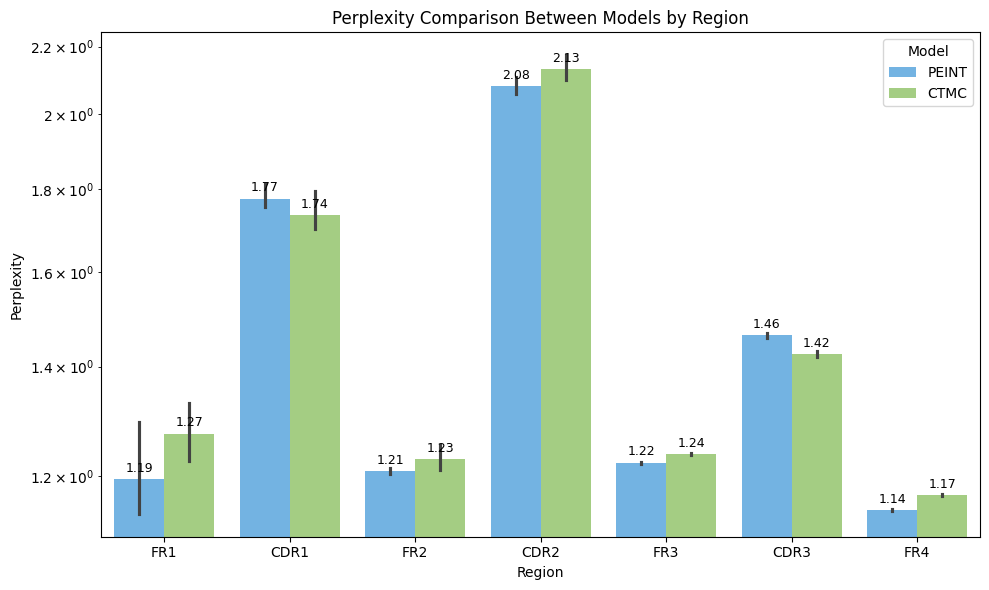

In [11]:
# for each region, plot the mean and standard deviation of the perplexity, colored by method
# don't use a boxplot, use a bar plot with error bars instead
# plot 2 subplots: one for heavy chain and one for light chain

keys_to_use = ['FR1', 'CDR1', 'FR2', 'CDR2', 'FR3', 'CDR3', 'FR4']
palette = {'Codon': "#fbaf6d", 'Codon RV': "#ef6dfb", 'PEINT': "#60b6f4", 'PEINT 650M': "#1f77b4", 'DASM': "#ff7f0e", 'CTMC': "#a3d977"}
loc_final_df = final_df[final_df['model'].isin(palette.keys())]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=loc_final_df[loc_final_df['region'].isin(keys_to_use)],
    x='region',
    y='ppl',
    hue='model',
    palette=palette,
    errorbar=('ci', 95),
)
plt.yscale('log')

# Add mean values as text on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.title('Perplexity Comparison Between Models by Region')
plt.xlabel('Region')
plt.ylabel('Perplexity')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


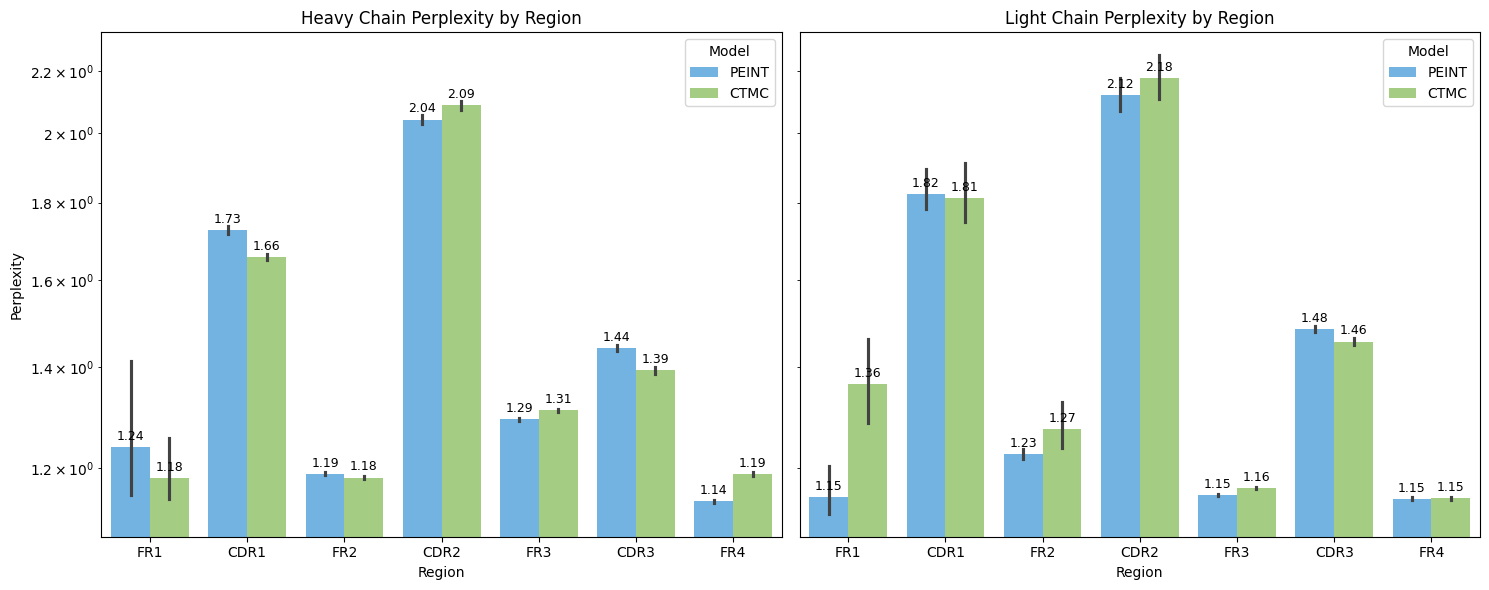

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
sns.barplot(
    data=loc_final_df[(loc_final_df['chain'] == 'heavy') & (loc_final_df['region'].isin(keys_to_use))],
    x='region',
    y='ppl',
    hue='model',
    palette=palette,
    errorbar=('ci', 95),
    ax=ax[0]
)
sns.barplot(
    data=loc_final_df[(loc_final_df['chain'] == 'light') & (loc_final_df['region'].isin(keys_to_use))],
    x='region',
    y='ppl',
    hue='model',
    palette=palette,
    errorbar=('ci', 95),
    ax=ax[1]
)
ax[0].set_title('Heavy Chain Perplexity by Region')
ax[0].set_xlabel('Region')
ax[0].set_ylabel('Perplexity')
ax[1].set_title('Light Chain Perplexity by Region')
ax[1].set_xlabel('Region')
ax[1].set_ylabel('')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].legend(title='Model')
ax[1].legend(title='Model')

# Add mean values as text on each bar
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.2f', padding=3, fontsize=9)

for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()